# Shea Homes Customer Review Analysis
### Notebook: `06_llm_analysis`

> Run `01_setup_and_summary_stats.ipynb` first, or execute the setup cell below.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

# keep apostrophes so contractions like "don't" stay as one token
TOKEN_PATTERN = r"(?u)\b\w[\w']+\b"

In [3]:
# load the dataset
df = pd.read_csv("../shea_homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# derived columns
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M")
df["quarter"] = df["date"].dt.to_period("Q")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,052 reviews
Date range: September 2020 to April 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness,word_count,char_count,state,year,year_month,quarter
0,Good overall,Constance G.,Yes,2026-04-01,"OCALA, FL",A little overwhelming for me as a single elder...,5,5,5,5,5,86,434,FL,2026,2026-04,2026Q2
1,"Excellent, knowledgeable and responsive",Emily V.,Yes,2026-03-31,"Littleton, CO",Our experience exceeded our expectations. The ...,5,5,5,5,5,32,218,CO,2026,2026-03,2026Q1
2,Overall great experience!,Lynn S.,Yes,2026-03-26,"Kuna, ID",This is our second Shea home! Our whole proces...,5,5,5,5,5,83,516,ID,2026,2026-03,2026Q1


In [4]:
# ── Prerequisites: compute sentiment columns ──
# (These are normally created in notebook 03_sentiment_analysis)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
scores = df["review_text"].apply(lambda x: sia.polarity_scores(str(x)))
df["vader_compound"] = scores.apply(lambda x: x["compound"])
df["vader_pos"] = scores.apply(lambda x: x["pos"])
df["vader_neg"] = scores.apply(lambda x: x["neg"])
df["vader_neu"] = scores.apply(lambda x: x["neu"])
df["vader_label"] = df["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral"))
df["textblob_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["textblob_label"] = df["textblob_polarity"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral"))

# stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["home","shea","homes","new","would","one","us","also","get","got",
    "even","like","really","much","could","said","told","went","going","still",
    "back","made","make","well","since","every"])
print(f"Sentiment columns ready. {len(df)} reviews, VADER pos/neg/neu computed.")


Sentiment columns ready. 2052 reviews, VADER pos/neg/neu computed.


---
# 6. Large Language Model Analysis (LLaMA 3.2 via Ollama)

### What is a Large Language Model?

Everything above used specialized tools, each designed to do one narrow task (score sentiment, classify topics, predict ratings). A LLM like Meta's LLaMA 3.2 is different. It's a general-purpose AI that can:

- Read and understand a review the way a human would
- Follow complex instructions ("categorize this review, extract action items, and draft a response")
- Produce natural language output, not just numbers

In [6]:
import ollama
import time
from tqdm import tqdm

def llm_response(prompt, model="llama3.2", system_prompt="You are a helpful assistant."):
    """Send a prompt to the local LLM and return its response."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    response = ollama.chat(model=model, messages=messages)
    return response["message"]["content"]

# quick test
print("Testing connection to LLaMA 3.2...")
test = llm_response("In one sentence, what is sentiment analysis?")
print(f"LLM response: {test}")
print("\nConnection successful!")

Testing connection to LLaMA 3.2...
LLM response: Sentiment analysis, also known as opinion mining or emotion AI, is the process of automatically determining the emotional tone or attitude conveyed by a piece of text, such as a review, comment, or social media post, to help humans understand and respond to customer feedback, market trends, and other data.

Connection successful!


## 6.1 Zero-Shot Sentiment Classification

**Zero-shot** means we give the LLM absolutely no examples. We just say: *"Is this review positive or negative?"* and it figures it out from its pre-trained understanding of language.

We'll run this on a stratified sample of 50 reviews (to keep runtime reasonable) and compare the LLM's accuracy against VADER.

In [8]:
# --- ZERO-SHOT CLASSIFICATION ---
# sample 50 reviews: 25 positive (4-5 Stars) and 25 negative/neutral (1-3 Stars)
pos_sample = df[df["total_score"] >= 4].sample(25, random_state=42)
neg_sample = df[df["total_score"] <= 3].sample(25, random_state=42)
sample = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
sample["true_label"] = sample["total_score"].apply(lambda x: "POSITIVE" if x >= 4 else "NEGATIVE")

def zero_shot_prompt(review_text):
    return (
        "Classify the sentiment of the following home builder review as either "
        "POSITIVE or NEGATIVE. Respond with ONLY one word: POSITIVE or NEGATIVE.\n\n"
        f"Review: {review_text}\n\n"
        "Sentiment:"
    )

def parse_sentiment_label(response_text):
    """Parse LLM output to a clean label."""
    text = response_text.strip().lower()
    if "positive" in text:
        return "POSITIVE"
    elif "negative" in text:
        return "NEGATIVE"
    return "POSITIVE"  # default if ambiguous

# run zero-shot on the sample
print("Running zero-shot classification on 50 reviews with LLaMA 3.2...")
zero_shot_preds = []
zero_shot_raw = []

for review in tqdm(sample["review_text"], desc="Zero-Shot"):
    prompt = zero_shot_prompt(str(review)[:500])  # truncate very long reviews
    response = llm_response(prompt)
    zero_shot_raw.append(response)
    zero_shot_preds.append(parse_sentiment_label(response))

sample["zs_pred"] = zero_shot_preds
sample["zs_raw"] = zero_shot_raw

# also get VADER predictions for the same sample
sample["vader_score"] = sample["review_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
sample["vader_pred"] = sample["vader_score"].apply(lambda x: "POSITIVE" if x >= 0.05 else "NEGATIVE")

# compare
zs_acc = (sample["zs_pred"] == sample["true_label"]).mean()
vader_acc = (sample["vader_pred"] == sample["true_label"]).mean()

print(f"\n{'='*55}")
print(f"  ZERO-SHOT RESULTS (50 reviews)")
print(f"{'='*55}")
print(f"  {'Method':<25} {'Accuracy':<15}")
print(f"  {'-'*40}")
print(f"  {'LLaMA 3.2 (Zero-Shot)':<25} {zs_acc:<15.1%}")
print(f"  {'VADER':<25} {vader_acc:<15.1%}")
print(f"{'='*55}")

Running zero-shot classification on 50 reviews with LLaMA 3.2...


Zero-Shot: 100%|███████████████████████████████████████| 50/50 [00:11<00:00,  4.40it/s]


  ZERO-SHOT RESULTS (50 reviews)
  Method                    Accuracy       
  ----------------------------------------
  LLaMA 3.2 (Zero-Shot)     86.0%          
  VADER                     76.0%          


## 6.2 Few-Shot At-Risk Detection

**Few-shot** means we give the LLM a few labeled examples before asking it to classify. This is like training a new employee by showing them: *"Here's what a happy customer sounds like. Here's what an unhappy one sounds like. Now you classify the rest."*

We'll give it 2 positive and 2 negative examples, then test on the same 50 reviews.

In [10]:
# --- FEW-SHOT CLASSIFICATION ---
# select demonstration examples (NOT from the test sample)
test_indices = set(sample.index)

# pick 2 clear positive and 2 clear negative reviews as examples
pos_pool = df[(df["total_score"] == 5) & (~df.index.isin(test_indices))]
neg_pool = df[(df["total_score"] == 1) & (~df.index.isin(test_indices))]

fs_pos_examples = pos_pool.sample(2, random_state=7)["review_text"].tolist()
fs_neg_examples = neg_pool.sample(2, random_state=7)["review_text"].tolist()

print("Few-shot examples selected:\n")
for i, ex in enumerate(fs_pos_examples):
    print(f"  POSITIVE example {i+1}: \"{str(ex)[:120]}...\"")
for i, ex in enumerate(fs_neg_examples):
    print(f"  NEGATIVE example {i+1}: \"{str(ex)[:120]}...\"")

def few_shot_prompt(review_text):
    return (
        "Classify this home builder review as POSITIVE or NEGATIVE.\n"
        "Respond with ONLY one word: POSITIVE or NEGATIVE.\n\n"
        "--- Examples ---\n"
        f"Review: {str(fs_pos_examples[0])[:300]}\n"
        "Sentiment: POSITIVE\n\n"
        f"Review: {str(fs_neg_examples[0])[:300]}\n"
        "Sentiment: NEGATIVE\n\n"
        f"Review: {str(fs_pos_examples[1])[:300]}\n"
        "Sentiment: POSITIVE\n\n"
        f"Review: {str(fs_neg_examples[1])[:300]}\n"
        "Sentiment: NEGATIVE\n\n"
        "--- Now classify this review ---\n"
        f"Review: {review_text}\n\n"
        "Sentiment:"
    )

# run few-shot
print("\nRunning few-shot classification on 50 reviews with LLaMA 3.2...")
fs_preds = []
fs_raw = []

for review in tqdm(sample["review_text"], desc="Few-Shot"):
    prompt = few_shot_prompt(str(review)[:500])
    response = llm_response(prompt)
    fs_raw.append(response)
    fs_preds.append(parse_sentiment_label(response))

sample["fs_pred"] = fs_preds
sample["fs_raw"] = fs_raw
fs_acc = (sample["fs_pred"] == sample["true_label"]).mean()

print(f"\n{'='*60}")
print(f"  COMPARISON: VADER vs Zero-Shot vs Few-Shot")
print(f"{'='*60}")
print(f"  {'Method':<30} {'Accuracy':<15}")
print(f"  {'-'*45}")
print(f"  {'VADER (rule-based)':<30} {vader_acc:<15.1%}")
print(f"  {'LLaMA 3.2 Zero-Shot':<30} {zs_acc:<15.1%}")
print(f"  {'LLaMA 3.2 Few-Shot':<30} {fs_acc:<15.1%}")
print(f"{'='*60}")

Few-shot examples selected:

  POSITIVE example 1: "From the beginning with Keith and the middle with Mike and end with Tina was a spectacular experience. We’re here proud ..."
  POSITIVE example 2: "I think overall builder is good..."
  NEGATIVE example 1: "I had a really bad experience with Shea. I was given the wrong information since the beginning, and just went downhill f..."
  NEGATIVE example 2: "A bunch of stuff wrong with the house and I can't get anything fixed...."

Running few-shot classification on 50 reviews with LLaMA 3.2...


Few-Shot: 100%|████████████████████████████████████████| 50/50 [00:11<00:00,  4.47it/s]


  COMPARISON: VADER vs Zero-Shot vs Few-Shot
  Method                         Accuracy       
  ---------------------------------------------
  VADER (rule-based)             76.0%          
  LLaMA 3.2 Zero-Shot            86.0%          
  LLaMA 3.2 Few-Shot             86.0%          


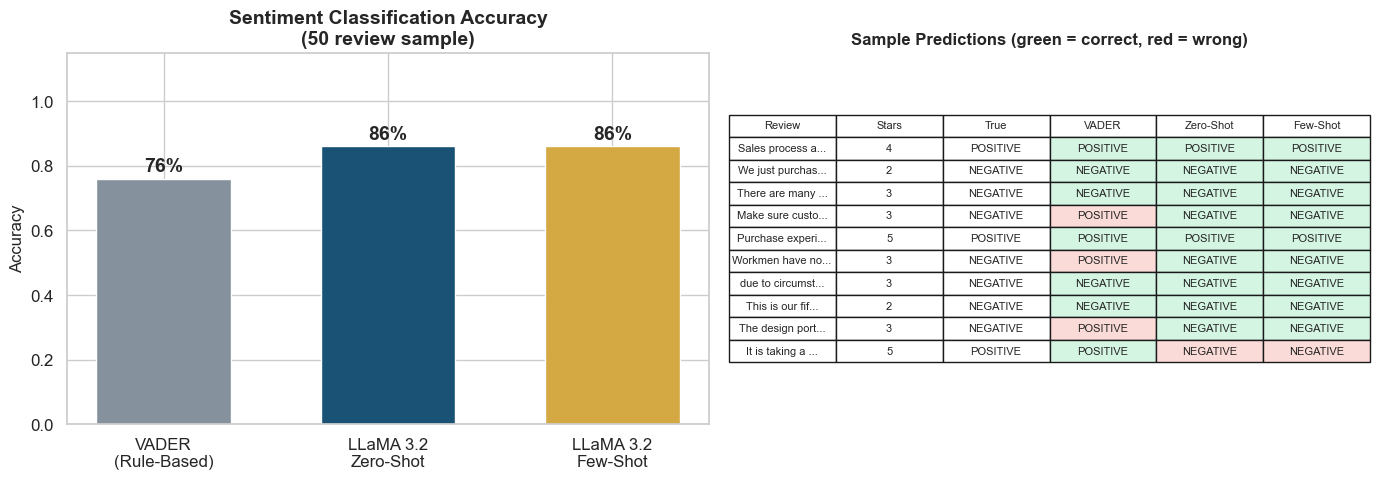

In [11]:
# visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: accuracy comparison
methods = ["VADER\n(Rule-Based)", "LLaMA 3.2\nZero-Shot", "LLaMA 3.2\nFew-Shot"]
accuracies = [vader_acc, zs_acc, fs_acc]
colors = ["#85929e", SHEA_BLUE, SHEA_GOLD]
bars = axes[0].bar(methods, accuracies, color=colors, edgecolor="white", width=0.6)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{acc:.0%}", ha="center", va="bottom", fontsize=14, fontweight="bold")
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Sentiment Classification Accuracy\n(50 review sample)", fontsize=14, fontweight="bold")

# right: sample predictions table
display_cols = sample[["review_text", "total_score", "true_label", "vader_pred", "zs_pred", "fs_pred"]].head(10).copy()
display_cols["review_text"] = display_cols["review_text"].apply(lambda x: str(x)[:15] + "...")
display_cols.columns = ["Review", "Stars", "True", "VADER", "Zero-Shot", "Few-Shot"]

# build a text table on the right axis
axes[1].axis("off")
table = axes[1].table(
    cellText=display_cols.values,
    colLabels=display_cols.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# color code: green if correct, red if wrong
for i in range(len(display_cols)):
    true_label = display_cols.iloc[i]["True"]
    for j, col in enumerate(["VADER", "Zero-Shot", "Few-Shot"]):
        pred = display_cols.iloc[i][col]
        color = "#d5f5e3" if pred == true_label else "#fadbd8"
        table[i + 1, j + 3].set_facecolor(color)

axes[1].set_title("Sample Predictions (green = correct, red = wrong)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 6.3 Deep Review Intelligence

This is where the LLM truly separates itself from traditional NLP tools. Instead of just outputting "positive" or "negative," we ask it to read the review like a business analyst and produce a structured intelligence report.

In [13]:
ANALYST_SYSTEM_PROMPT = (
    "You are a customer experience analyst at Shea Homes, a major home builder. "
    "You analyze customer reviews to extract actionable business intelligence. "
    "Be specific, concise, and business-focused."
)

def deep_review_prompt(review_text, star_rating, location):
    return (
        f"Analyze this verified homebuyer review for Shea Homes.\n\n"
        f"RATING: {star_rating}/5 stars\n"
        f"LOCATION: {location}\n"
        f"REVIEW: \"{review_text}\"\n\n"
        f"Provide your analysis in this EXACT format:\n\n"
        f"CATEGORY: [Sales Experience | Construction Quality | Warranty & Service | "
        f"Communication | Design & Features | Value & Pricing | General Praise | Multiple Issues]\n"
        f"SENTIMENT: [Positive | Negative | Mixed]\n"
        f"KEY THEMES: [2-4 specific themes]\n"
        f"ACTION ITEMS: [1-3 specific, actionable next steps for the Shea team]\n"
        f"URGENCY: [Low | Medium | High | Critical]\n"
    )

# select diverse reviews to demo
demo_reviews = pd.concat([
    df[df["total_score"] == 1].sample(1, random_state=10),
    df[df["total_score"] == 2].sample(1, random_state=5),
    df[df["total_score"] == 5].sample(1, random_state=20),
])


for _, row in demo_reviews.iterrows():
    print("=" * 70)
    text = str(row["review_text"])
    print(f"REVIEW INPUT: {row['total_score']}Stars | {row['location']}")
    print(f'"{text[:400]}{"..." if len(text) > 400 else ""}"')
    
    prompt = deep_review_prompt(text[:600], row["total_score"], row["location"])
    analysis = llm_response(prompt, system_prompt=ANALYST_SYSTEM_PROMPT)
    
    print(f"\nLLaMA 3.2 ANALYSIS:")
    print(analysis)
    print()

REVIEW INPUT: 1Stars | Denver, NC
"Because this review is going on a public website, I am limiting the review to a summary statement. Overall, the buying experience was poor, which is a shame because as the home buying market shifts and there are fewer buyers, customer service will be the key to future sales."

LLaMA 3.2 ANALYSIS:
CATEGORY: Sales Experience
SENTIMENT: Negative
KEY THEMES:
1. Poor customer service and buying experience
2. Impact of market shift on future sales
3. Perception that customer service will be crucial to future success

ACTION ITEMS:
1. Conduct a review of the company's sales process and identify areas for improvement in terms of communication, transparency, and issue resolution.
2. Develop a training program for sales team members to focus on customer-centric skills and empathy-building.
3. Establish clear metrics to measure customer satisfaction and implement data-driven strategies to address emerging market trends.

URGENCY: Medium

REVIEW INPUT: 2Stars | W

## 6.4 AI-Generated Executive Briefing

In [15]:
# compile the 20 most recent reviews into a briefing
recent = df.nlargest(20, "date")

review_block = "\n".join([
    f"- [{row['total_score']} Stars, {row['location']}] {str(row['review_text'])[:200]}"
    for _, row in recent.iterrows()
])

briefing_prompt = (
    f"Below are {len(recent)} recent customer reviews for Shea Homes.\n"
    f"Write a concise EXECUTIVE BRIEFING for a director who has 2 minutes to read it.\n\n"
    f"REVIEWS:\n{review_block}\n\n"
    f"Format your briefing as:\n"
    f"1. OVERALL PULSE: One sentence on general customer sentiment\n"
    f"2. TOP POSITIVES: 2-3 things customers love most, with evidence\n"
    f"3. TOP CONCERNS: 2-3 most common complaints, with evidence\n"
    f"4. REGIONAL NOTES: Any patterns by location\n"
    f"5. RECOMMENDED ACTIONS: 3 specific, prioritized next steps\n\n"
    f"Be direct and actionable. No fluff."
)

print("=" * 70)
print("AI-GENERATED EXECUTIVE BRIEFING")
print(f"Based on the 20 most recent reviews")
print(f"({recent['date'].min().strftime('%b %Y')} to {recent['date'].max().strftime('%b %Y')})")
print("=" * 70)

briefing = llm_response(briefing_prompt, system_prompt=ANALYST_SYSTEM_PROMPT)
print(briefing)

AI-GENERATED EXECUTIVE BRIEFING
Based on the 20 most recent reviews
(Feb 2026 to Apr 2026)
**EXECUTIVE BRIEFING**

**OVERALL PULSE:** Overall customer sentiment is positive, with an average rating of 4.2/5 stars across the 20 reviews.

**TOP POSITIVES:**

1. **Exceptional Customer Service**: Multiple customers praised the team's knowledge, responsiveness, and follow-up on every aspect of their experience (e.g., [5 Stars, Littleton, CO], [5 Stars, Kuna, ID]). Sales associates like Jasmine and Ryan were particularly commended for their excellence.
2. **Smooth Buying Experience**: Several buyers reported a seamless process from initial contact to closing, with everyone from sales to builders being friendly and accommodating (e.g., [5 Stars, San Marcos, CA], [3 Stars, Las Vegas, NV]).
3. **Quality of Amenities**: Customers appreciated the quality of amenities in the communities, including landscaping and community activities (e.g., [3 Stars, Denver, NC]).

**TOP CONCERNS:**

1. **Staff Tur